In [1]:
import os
import pandas as pd
import torch
from torchinfo import summary
from transformers import AutoModelForSpeechSeq2Seq, AutoProcessor, pipeline
from datasets import load_dataset, Audio, Dataset

from utils import join_segments, clean_text, display_by_duration

In [2]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 600)

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32
device

'cuda:0'

In [3]:
rec_path = os.path.join('inputs', 'rec_pre.mp3')
seg_path = os.path.join('outputs', 'segments.parquet')
text_path = os.path.join('outputs', 'transcript.txt')

In [4]:
model_id = 'openai/whisper-large-v3'

model = AutoModelForSpeechSeq2Seq.from_pretrained(
    model_id,
    torch_dtype=torch_dtype,
    low_cpu_mem_usage=True,
    use_safetensors=True
)
model.to(device)

model.generation_config.cache_implementation = 'static'
model.forward = torch.compile(model.forward, mode='reduce-overhead', fullgraph=True)

processor = AutoProcessor.from_pretrained(model_id)

In [5]:
summary(model)

Layer (type:depth-idx)                                  Param #
WhisperForConditionalGeneration                         --
├─WhisperModel: 1-1                                     --
│    └─WhisperEncoder: 2-1                              --
│    │    └─Conv1d: 3-1                                 492,800
│    │    └─Conv1d: 3-2                                 4,916,480
│    │    └─Embedding: 3-3                              (1,920,000)
│    │    └─ModuleList: 3-4                             629,637,120
│    │    └─LayerNorm: 3-5                              2,560
│    └─WhisperDecoder: 2-2                              --
│    │    └─Embedding: 3-6                              66,388,480
│    │    └─WhisperPositionalEmbedding: 3-7             573,440
│    │    └─ModuleList: 3-8                             839,557,120
│    │    └─LayerNorm: 3-9                              2,560
├─Linear: 1-2                                           66,388,480
Total params: 1,609,879,040
Trainable params

In [6]:
dataset = Dataset.from_dict({'audio': [rec_path]})
dataset = dataset.cast_column('audio', Audio(processor.feature_extractor.sampling_rate))
audio = dataset[0]['audio']

In [7]:
inputs = processor(
    audio['array'],
    sampling_rate=audio['sampling_rate'],
    return_tensors='pt',
    truncation=False,
    padding='longest',
    return_attention_mask=True,
    predict_timestamps=True
)
inputs = inputs.to(device, dtype=torch_dtype)

In [8]:
prompt_ids = torch.tensor(processor.get_prompt_ids('onto' 'promortalist' 'promortalism'), device=device)

gen_kwargs = {
    'language': 'en',
    'return_timestamps': True,
    'return_segments': True,
    'prompt_ids': prompt_ids,
    #'return_token_timestamps': True
}

torch.compiler.cudagraph_mark_step_begin()

pred_ids = model.generate(**inputs, **gen_kwargs)

You have passed language=en, but also have set `forced_decoder_ids` to [[1, None], [2, 50360]] which creates a conflict. `forced_decoder_ids` will be ignored in favor of language=en.
W0909 08:04:47.478000 15639 torch/_inductor/utils.py:1436] [0/1] Not enough SMs to use max_autotune_gemm mode
CUDAGraph supports dynamic shapes by recording a new graph for each distinct input size. Recording too many CUDAGraphs may lead to extra overhead. We have observed 51 distinct sizes. Please consider the following options for better performance: a) padding inputs to a few fixed number of shapes; or b) set torch._inductor.config.triton.cudagraph_skip_dynamic_graphs=True. Set torch._inductor.config.triton.cudagraph_dynamic_shape_warn_limit=None to silence this warning.


In [9]:
pred_text = processor.batch_decode(pred_ids['sequences'], skip_special_tokens=True)[0].strip()
with open(text_path, 'w') as f:
  f.write(clean_text(pred_text))

In [10]:
segments = pd.DataFrame.from_records(pred_ids['segments'][0], coerce_float=True)[['start', 'end', 'tokens']]
decoded = segments['tokens'].map(lambda x: processor.decode(x, skip_special_tokens=True).strip())
segments['text'] = clean_text(decoded)
segments['duration'] = segments.end - segments.start
segments = segments[['start', 'end', 'duration', 'text']]
segments[:10]

,start,end,duration,text
0,0.000000,7.720000,7.720000,"Okay, so I figured I would just make a recording explaining why I've decided to bomb an IVF building or clinic."
1,10.060000,14.160000,4.099999,"Basically, it just comes down to I'm angry that I exist."
2,15.200000,18.780001,3.580001,"And that's, you know, nobody got my consent to bring me here."
3,18.959999,20.120001,1.160002,And I know what you're going to say.
4,20.340000,23.600000,3.260000,"How could we have got your consent because you didn't exist, blah, blah, blah."
5,24.420000,25.240000,0.820000,Exactly the point.
6,25.879999,27.920000,2.040001,There's no way you can get consent to bring someone here.
7,28.000000,29.020000,1.020000,So don't fucking do it.
8,29.120001,29.340000,0.219999,Right.
9,29.340000,33.360001,4.020000,um and if you're going to try to say something really fucking retarded like


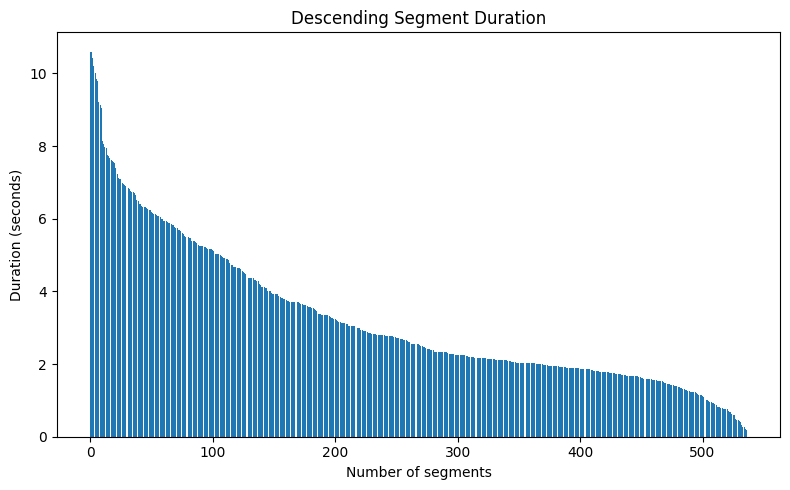

In [11]:
display_by_duration(segments)

In [12]:
segments.index = join_segments(segments.duration)

agg_segments = (
    segments.groupby(level=0)
            .agg({'start': 'first', 'end': 'last', 'duration': 'sum', 'text': ' '.join})
            .reset_index(drop=True)
)
agg_segments[:10]

,start,end,duration,text
0,0.000000,7.720000,7.720000,"Okay, so I figured I would just make a recording explaining why I've decided to bomb an IVF building or clinic."
1,10.060000,14.160000,4.099999,"Basically, it just comes down to I'm angry that I exist."
2,15.200000,18.780001,3.580001,"And that's, you know, nobody got my consent to bring me here."
3,18.959999,23.600000,4.420002,"And I know what you're going to say. How could we have got your consent because you didn't exist, blah, blah, blah."
4,24.420000,29.020000,3.880001,Exactly the point. There's no way you can get consent to bring someone here. So don't fucking do it.
5,29.120001,33.360001,4.240000,Right. um and if you're going to try to say something really fucking retarded like
6,33.360001,37.380001,4.020000,well since you don't exist you don't have a consent status and therefore we don't have to
7,37.380001,43.619999,6.239998,get consent this really isn't any different from saying oh well the girl's unconscious so i can't
8,43.619999,49.599998,5.980000,get you know i can't get her consent to have sex with her so therefore it's okay because i can't
9,49.599998,54.860001,5.260002,there's no way to even ask for the consent right um so i mean if you actually think that's a good


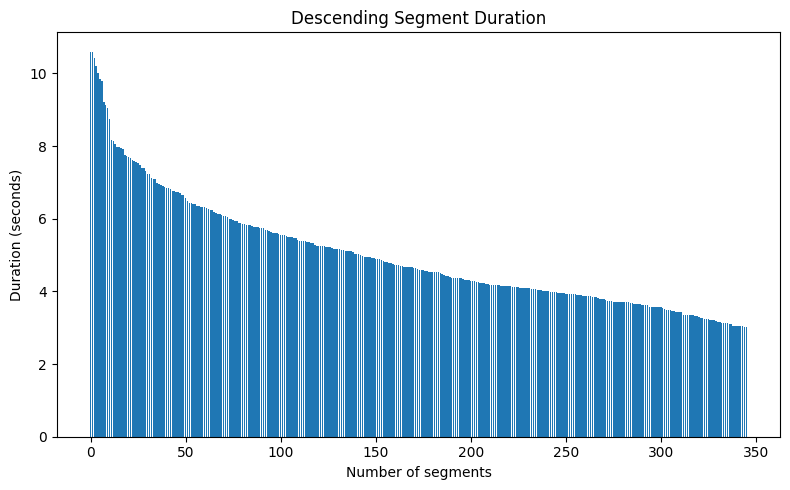

In [13]:
display_by_duration(agg_segments)

In [14]:
agg_segments[['start', 'end', 'text']].to_parquet(seg_path)